Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital\
**Tecnología Digital VI: Inteligencia Artificial**

# **Aplicación de perceptrones**

### **Carga y visualización de los datos**

In [14]:
# !pip install torchvision
import torchvision

In [15]:
mnist_train = torchvision.datasets.MNIST(root = './data',
                                         train = True,
                                         download = True,
                                         transform = torchvision.transforms.ToTensor())

mnist_test = torchvision.datasets.MNIST(root = './data',
                                        train = False,
                                        download = True,
                                        transform = torchvision.transforms.ToTensor())

# Enlace a la documentación oficial: https://pytorch.org/vision/0.15/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST

In [16]:
mnist_train.data

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [17]:
import matplotlib.pyplot as plt

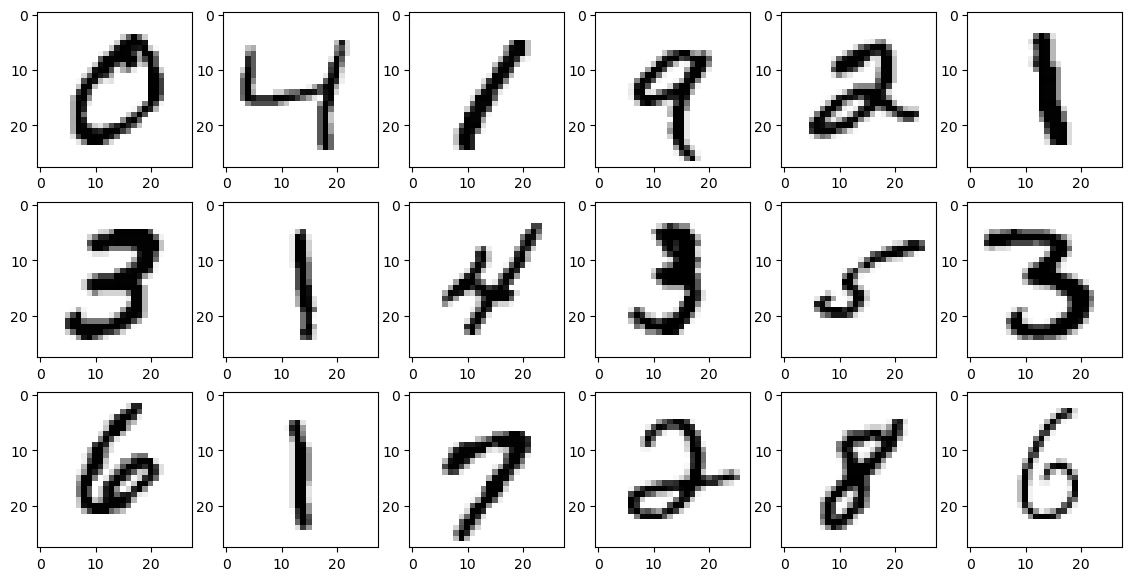

In [18]:
plt.rcParams['figure.figsize'] = [14, 7]

for i in range(1, 19):
    plt.subplot(3, 6, i)
    plt.imshow(mnist_train.data[i, :, :], cmap = plt.get_cmap('gray_r'))
    # _r para invertir el color del fondo con el del dígito manuscrito (ver
    # imagen en las diapositivas).

In [19]:
X_train = mnist_train.data.view(-1, 784)
X_test = mnist_test.data.view(-1, 784)

In [20]:
print(X_train.shape)
print(X_test.shape)

torch.Size([60000, 784])
torch.Size([10000, 784])


In [21]:
mnist_train.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [22]:
print(mnist_train.targets)
print(len(mnist_train.targets))

tensor([5, 0, 4,  ..., 5, 6, 8])
60000


In [23]:
y_train = mnist_train.targets
y_test = mnist_test.targets

In [24]:
print(y_train.shape)
print(y_test.shape)

torch.Size([60000])
torch.Size([10000])


### **Perceptrón simple**

In [25]:
from sklearn.linear_model import Perceptron

In [26]:
simple = Perceptron() # Creamos la instancia.
simple.fit(X_train, y_train) # La entrenamos.
simple.score(X_test, y_test) # La evaluamos (accuracy).

# Enlace a la documentación oficial: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html

0.8897

In [27]:
import torch

In [28]:
# Comparamos la y predicha con la y real, para las primeras 10 imágenes.
print(f'Predichas: {torch.from_numpy(simple.predict(X_test[0:10, ]))}')
print(f'Reales:    {y_test[0:10]}')

Predichas: tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9])
Reales:    tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


### **Perceptrón monocapa**

In [29]:
import torch.nn as nn
import torch.nn.functional as F

In [30]:
class oneLayer(torch.nn.Module):

    def __init__(self, n_features, size_hidden, n_outputs):
        super(oneLayer, self).__init__()
        self.hidden = nn.Linear(in_features = n_features,
                                out_features = size_hidden)
        self.out = nn.Linear(in_features = size_hidden,
                             out_features = n_outputs)

    def forward(self, x):
        x = x.view(-1, 784) # Le vamos a pasar mnist_train, en vez de X_train.
        x = F.leaky_relu(self.hidden(x))
        # Función de activación elegida: leaky ReLU.
        # ReLU: Rectified Linear Unit.
        # Más información sobre funciones de activación en próximas clases.
        x = self.out(x)
        return x

In [31]:
n_features = 784
size_hidden = 15
n_outputs = 10

batch_size = 50
# Tamaño de las muestras a extraer de los datos.
# Los pesos del modelo se actualizan luego de analizar una muestra.
# Entonces, el modelo se actualizará 60.000 / 50 = 1.200 veces.

learning_rate = 0.0001
# Tasa de aprendizaje para el gradiente descendente.
# Asignamos el mismo valor que el valor por defecto en el método Perceptron.

n_epochs = 5
# Cantidad de veces que se recorrerá por completo el conjunto de datos de entrenamiento.
# Entonces, el modelo se terminará actualizando 1.200 * 5 = 6.000 veces.

In [32]:
from torch.utils.data import DataLoader

In [33]:
one_layer = oneLayer(n_features = n_features,
                     size_hidden = size_hidden,
                     n_outputs = n_outputs)

optimizer = torch.optim.Adam(params = one_layer.parameters(),
                             lr = learning_rate)
# Enlace doc. oficial torch.optim: https://pytorch.org/docs/stable/optim.html
# Enlace doc. oficial Adam: https://pytorch.org/docs/stable/generated/torch.optim.Adam.html

criterion = nn.CrossEntropyLoss()
# La función de pérdida.
# Enlace a la documentación oficial: https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

loader_train = DataLoader(dataset = mnist_train,
                          batch_size = batch_size,
                          shuffle = True)
# Es iterable.

loss_values = []
# Donde guardaremos el valor de la función de pérdida para las 6.000 actualizaciones.

# Generamos el bucle de entrenamiento.
for epoch in range(n_epochs):
    for x_train, y_train in loader_train:
        optimizer.zero_grad() # Inicializamos en cero los gradientes de los párametros.
        loss = criterion(one_layer(x_train), y_train) # Realizamos la pasada forward.
        loss.backward()
        optimizer.step() # Actualizamos los pesos.
        loss_values.append(loss.data.item())
    print(f'Epoch {epoch + 1}, loss = {loss}')

Epoch 1, loss = 0.8379414081573486
Epoch 2, loss = 0.43707001209259033
Epoch 3, loss = 0.6489881873130798
Epoch 4, loss = 0.3873864710330963
Epoch 5, loss = 0.428521066904068


In [34]:
import numpy as np

Text(0.5, 1.0, 'Función de pérdida (promedio por muestra) durante el entrenamiento')

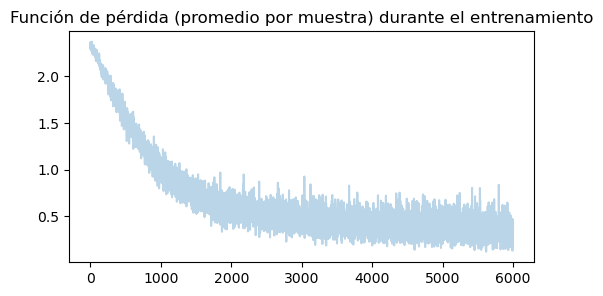

In [35]:
plt.rcParams['figure.figsize'] = [6, 3]
plt.figure()
plt.plot(np.array(loss_values), alpha = 0.3)
plt.title('Función de pérdida (promedio por muestra) durante el entrenamiento')

In [36]:
torch.save(one_layer.state_dict(), './one-layer.pth')

In [37]:
# # Para cargar el modelo, los pasos son los siguientes.
# one_layer = oneLayer(n_features = n_features,
#                      size_hidden = size_hidden,
#                      n_outputs = n_outputs)
# one_layer.load_state_dict(torch.load('./one-layer.pth'))

In [38]:
from sklearn.metrics import classification_report

In [39]:
loader_test = DataLoader(dataset = mnist_test,
                         batch_size = mnist_test.data.shape[0],
                         shuffle = False)

x_test = list(loader_test)[0][0]
y_test = list(loader_test)[0][1]

pred_prob_test = one_layer(x_test)
pred_class_test = torch.max(pred_prob_test.to('cpu'), 1)[1].data.numpy()

print(classification_report(y_test, pred_class_test))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       980
           1       0.96      0.98      0.97      1135
           2       0.91      0.88      0.90      1032
           3       0.88      0.90      0.89      1010
           4       0.90      0.93      0.92       982
           5       0.89      0.82      0.85       892
           6       0.92      0.94      0.93       958
           7       0.90      0.90      0.90      1028
           8       0.85      0.86      0.86       974
           9       0.89      0.87      0.88      1009

    accuracy                           0.91     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.91      0.91      0.91     10000



### **Perceptrón multicapa**

In [40]:
class twoLayersSameSize(torch.nn.Module):

    def __init__(self, n_features, size_hidden, n_outputs):
        super(twoLayersSameSize, self).__init__()
        self.hidden_1 = nn.Linear(in_features = n_features, out_features = size_hidden)
        self.hidden_2 = nn.Linear(in_features = size_hidden, out_features = size_hidden)
        self.out = nn.Linear(in_features = size_hidden, out_features = n_outputs)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.leaky_relu(self.hidden_1(x))
        x = F.leaky_relu(self.hidden_2(x))
        x = self.out(x)
        return x

In [41]:
def twoLayersSameSize_vary_size_hidden(n_features, size_hidden, n_outputs):
    two_layers = twoLayersSameSize(n_features, size_hidden, n_outputs)

    optimizer = torch.optim.Adam(params = two_layers.parameters(),
                                 lr = learning_rate)

    criterion = nn.CrossEntropyLoss()

    loader_train = DataLoader(dataset = mnist_train,
                              batch_size = batch_size,
                              shuffle = True)

    loss_values = []

    for epoch in range(n_epochs):
        for x_train, y_train in loader_train:
            optimizer.zero_grad()
            loss = criterion(two_layers(x_train), y_train)
            loss.backward()
            optimizer.step()
            loss_values.append(loss.data.item())
        print(f'Epoch {epoch + 1}, loss = {loss}')

    fig, axs = plt.subplots(1, 2, figsize = (12, 3))
    fig.suptitle(size_hidden)

    axs[0].plot(np.array(loss_values), alpha = 0.3)
    axs[0].set_title('\nFunción de pérdida (promedio por muestra) durante el entrenamiento')
    axs[0].set_xlim([-100, 6100])
    axs[0].set_ylim([-0.2, 2.6])

    pred_prob_test = two_layers(x_test)
    pred_class_test = torch.max(pred_prob_test.to('cpu'), 1)[1].data.numpy()
    print(classification_report(y_test, pred_class_test))

    pred_prob_train = two_layers(x_train)
    pred_class_train = torch.max(pred_prob_train.to('cpu'), 1)[1].data.numpy()
    axs[1].scatter(y_train, pred_class_train, alpha = 0.3)
    axs[1].set_title('\nValor real vs. predicción para datos de entrenamiento')
    axs[1].set_xlabel('Valor real')
    axs[1].set_ylabel('Predicción')

Cantidad de neuronas en cada capa oculta: 2
Epoch 1, loss = 2.228827476501465
Epoch 2, loss = 1.9184448719024658
Epoch 3, loss = 1.8664462566375732
Epoch 4, loss = 1.8872112035751343
Epoch 5, loss = 1.7218611240386963
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       980
           1       0.71      0.41      0.52      1135
           2       0.00      0.00      0.00      1032
           3       0.21      0.62      0.31      1010
           4       0.44      0.61      0.51       982
           5       0.29      0.24      0.26       892
           6       0.58      0.67      0.62       958
           7       0.28      0.18      0.22      1028
           8       0.51      0.51      0.51       974
           9       0.36      0.52      0.42      1009

    accuracy                           0.38     10000
   macro avg       0.34      0.38      0.34     10000
weighted avg       0.34      0.38      0.34     10000


Cantidad de neuronas e

/home/chipi/anaconda3/envs/td-vi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chipi/anaconda3/envs/td-vi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chipi/anaconda3/envs/td-vi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Epoch 1, loss = 1.2040247917175293
Epoch 2, loss = 1.0631754398345947
Epoch 3, loss = 0.6453158855438232
Epoch 4, loss = 0.7591271996498108
Epoch 5, loss = 0.6107848882675171
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       980
           1       0.93      0.97      0.95      1135
           2       0.88      0.81      0.85      1032
           3       0.80      0.81      0.81      1010
           4       0.84      0.84      0.84       982
           5       0.81      0.67      0.73       892
           6       0.86      0.90      0.88       958
           7       0.93      0.87      0.90      1028
           8       0.72      0.72      0.72       974
           9       0.75      0.84      0.79      1009

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000


Cantidad de neuronas en cada capa oculta: 200
Epoch 1, loss = 0.3

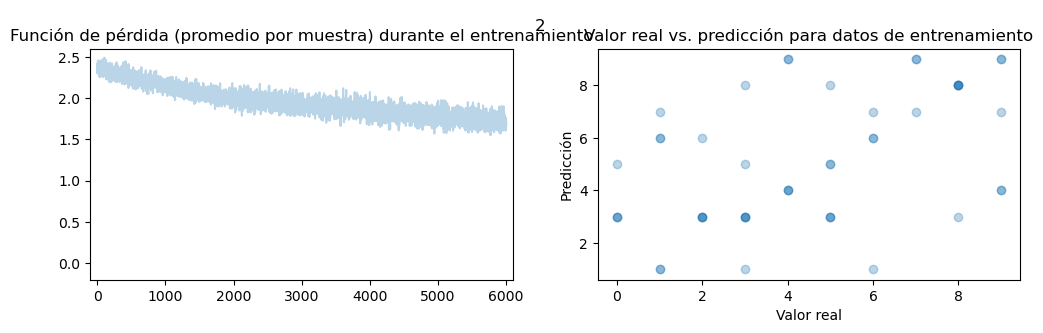

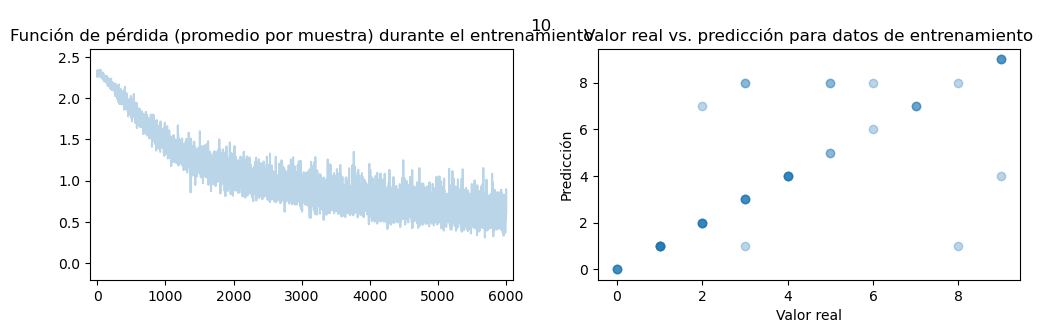

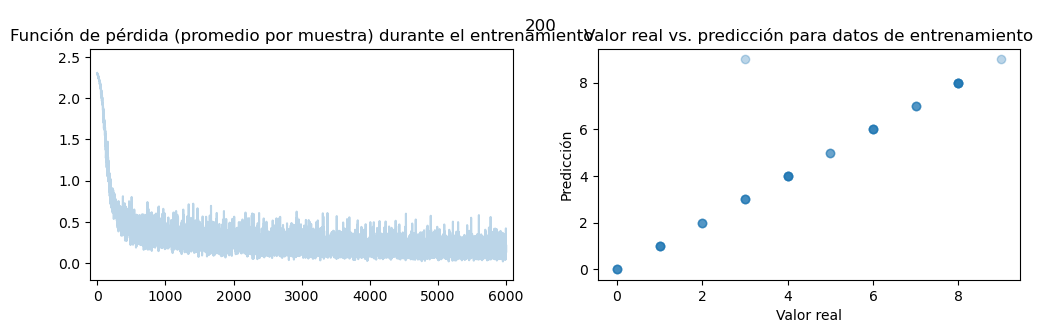

In [42]:
for size in [2, 10, 200]:
    aux = '' if size == 2 else '\n'
    print(f'{aux}Cantidad de neuronas en cada capa oculta: {size}')
    two_layers = twoLayersSameSize_vary_size_hidden(n_features = n_features,
                                                    size_hidden = size,
                                                    n_outputs = n_outputs)

Y si, en vez de que el perceptrón multicapa sí o sí deba tener 2 capas ocultas del mismo tamaño, queremos que dichas cantidades sean arbitrarias (es decir, indicadas vía parámetros), ¿cómo hacemos?

In [43]:
class nLayersAnySize(torch.nn.Module):

    def __init__(self, n_features, size_every_hidden, n_outputs):
        super(nLayersAnySize, self).__init__()

        self.all_hidden = nn.ModuleList()
        self.input_size = n_features
        for i in range(len(size_every_hidden) - 1):
            self.all_hidden.append(nn.Linear(in_features = self.input_size,
                                             out_features = size_every_hidden[i]))
            self.input_size = size_every_hidden[i]

        self.out = # COMPLETAR.

    def forward(self, x):
        x = x.view(-1, 784)

        for hidden in self.all_hidden:
            x = F.leaky_relu(hidden(x))

        x = self.out(x)
        return x

SyntaxError: invalid syntax (2168629929.py, line 13)

In [ ]:
def nLayersAnySize_vary_sizes(n_features, size_every_hidden, n_outputs):
    n_layers = # COMPLETAR.

    optimizer = torch.optim.Adam(params = n_layers.parameters(),
                                 lr = learning_rate)

    criterion = nn.CrossEntropyLoss()

    loader_train = DataLoader(dataset = mnist_train,
                              batch_size = batch_size,
                              shuffle = True)

    loss_values = []

    for epoch in range(n_epochs):
        for x_train, y_train in loader_train:
            optimizer.zero_grad()
            loss = criterion(n_layers(x_train), y_train)
            loss.backward()
            optimizer.step()
            loss_values.append(loss.data.item())
        print(f'Epoch {epoch + 1}, loss = {loss}')

    pred_prob_test = n_layers(x_test)
    pred_class_test = torch.max(pred_prob_test.to('cpu'), 1)[1].data.numpy()
    print(classification_report(y_test, pred_class_test))

In [ ]:
n_layers = nLayersAnySize_vary_sizes(n_features = n_features,
                                     size_every_hidden = [10, 8, 6, 4],
                                     n_outputs = n_outputs)